# MobileNet

## Goal

The purpose of this notebook is to demonstrate the main idea behind MobileNet architecture.

MobileNet is designed for mobile and resource-constrained devices.

The key idea is to replace standard convolutions with depthwise separable convolutions.

In [1]:
import torch
import torch.nn as nn
from torchvision import models

## Standard Convolution vs Depthwise Separable Convolution

MobileNet reduces computation by splitting a standard convolution into two operations:

1. Depthwise convolution
2. Pointwise convolution

This significantly reduces the number of parameters.

In [2]:
standard_conv = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3
)

depthwise = nn.Conv2d(
    in_channels=32,
    out_channels=32,
    kernel_size=3,
    groups=32
)

pointwise = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=1
)

In [3]:
standard_params = sum(
    p.numel()
    for p in standard_conv.parameters()
)

depthwise_params = sum(
    p.numel()
    for p in depthwise.parameters()
)

pointwise_params = sum(
    p.numel()
    for p in pointwise.parameters()
)

mobilenet_params = depthwise_params + pointwise_params

print(f"Standard convolution parameters: {standard_params:,}")
print(f"Depthwise convolution parameters: {depthwise_params:,}")
print(f"Pointwise convolution parameters: {pointwise_params:,}")
print(f"Total MobileNet-style parameters: {mobilenet_params:,}")

Standard convolution parameters: 18,496
Depthwise convolution parameters: 320
Pointwise convolution parameters: 2,112
Total MobileNet-style parameters: 2,432


## Loading MobileNetV2

PyTorch provides a pretrained MobileNetV2 model that was trained on the ImageNet dataset.

In [4]:
mobilenet = models.mobilenet_v2(weights="DEFAULT")

print(type(mobilenet))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\teter/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100.0%


<class 'torchvision.models.mobilenetv2.MobileNetV2'>


## Exploring the Model

Let's inspect the architecture and number of parameters in MobileNetV2.

In [5]:
total_params = sum(
    p.numel()
    for p in mobilenet.parameters()
)

print(f"Total parameters: {total_params:,}")

Total parameters: 3,504,872


In [6]:
print(mobilenet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


## Comparison with ResNet18

MobileNet is designed to be much smaller and more efficient than traditional CNN architectures.

In [7]:
resnet = models.resnet18(weights="DEFAULT")

resnet_params = sum(
    p.numel()
    for p in resnet.parameters()
)

mobilenet_params = sum(
    p.numel()
    for p in mobilenet.parameters()
)

print(f"ResNet18 parameters: {resnet_params:,}")
print(f"MobileNetV2 parameters: {mobilenet_params:,}")

ResNet18 parameters: 11,689,512
MobileNetV2 parameters: 3,504,872


## Parameter Reduction

MobileNetV2 contains significantly fewer parameters than ResNet18.

This reduction makes MobileNet faster and more suitable for mobile and embedded devices.

In [8]:
reduction = resnet_params / mobilenet_params

print(f"ResNet18 is approximately {reduction:.2f} times larger than MobileNetV2.")

ResNet18 is approximately 3.34 times larger than MobileNetV2.


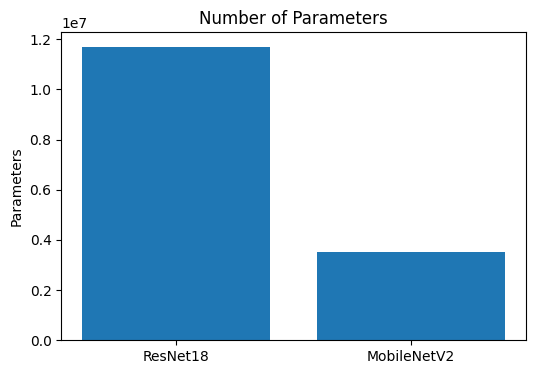

In [9]:
import matplotlib.pyplot as plt

models_names = ["ResNet18", "MobileNetV2"]
params = [resnet_params, mobilenet_params]

plt.figure(figsize=(6, 4))
plt.bar(models_names, params)

plt.title("Number of Parameters")
plt.ylabel("Parameters")

plt.show()

## Conclusion

MobileNet achieves high efficiency by using depthwise separable convolutions.

This greatly reduces the number of parameters and computational cost.

Therefore, MobileNet is widely used on smartphones, tablets and embedded devices.